# 🎤 Speech Enhancement — Step 2: Train the U-Net

This notebook:
1. Mounts Google Drive
2. Loads the spectrogram datasets created in notebook 01
3. Trains the U-Net speech-enhancement model
4. Saves the best weights back to Drive

### Prerequisites
- Run `01_Data_Preparation.ipynb` first, so spectrograms exist in Drive.
- Enable GPU in Colab: **Runtime → Change runtime type → GPU (T4)**

In [1]:
# ── 1. Mount Google Drive ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✓


In [2]:
# ── 2. Install dependencies ────────────────────────────────────────────────
%pip install -q librosa soundfile scikit-learn

In [3]:
# ── 3. Clone repo & add src/ to path ──────────────────────────────────────
import subprocess, sys, os

REPO = 'https://github.com/theweird-kid/speech_enhancement.git'  # <── update
REPO_DIR = '/content/speech_enhancement'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)

sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
print('Repo ready ✓')

Repo ready ✓


In [4]:
# ── 4. Configure training ──────────────────────────────────────────────────
import config as C

# Override any config values here if needed:
# C.EPOCHS     = 20
# C.BATCH_SIZE = 16
# C.TRAINING_FROM_SCRATCH = True

print(f'Epochs          : {C.EPOCHS}')
print(f'Batch size      : {C.BATCH_SIZE}')
print(f'From scratch    : {C.TRAINING_FROM_SCRATCH}')
print(f'Spectrogram dir : {C.SPEC_DIR}')
print(f'Weights dir     : {C.WEIGHTS_DIR}')

Epochs          : 10
Batch size      : 32
From scratch    : True
Spectrogram dir : /content/drive/MyDrive/speech_enhancement/data/spectrograms
Weights dir     : /content/drive/MyDrive/speech_enhancement/weights


In [5]:
# ── 5. Verify GPU is available ────────────────────────────────────────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)
if not gpus:
    print('⚠️  No GPU detected. Training will be slow. Enable GPU in Runtime settings.')

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ── 6. Preview the U-Net architecture ─────────────────────────────────────
from model import build_unet
model = build_unet()
model.summary()

Model: "SpeechEnhancement_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ leaky_re_lu[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ leaky_re_lu_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ leaky_re_lu_3[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ leaky_re_lu_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ leaky_re_lu_5[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[

 Total params: 1,941,093 (7.40 MB)

 Trainable params: 1,941,093 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

Loading spectrograms …
Data shape: (500, 128, 128)
Train: (450, 128, 128, 1)  Val: (50, 128, 128, 1)
Training from scratch …


Model: "SpeechEnhancement_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 128, 128,  │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_23      │ (None, 128, 128,  │          0 │ conv2d_24[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 128, 128,  │      2,320 │ leaky_re_lu_23[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_24      │ (None, 128, 128,  │          0 │ conv2d_25[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ leaky_re_lu_24[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 64, 64,    │          0 │ conv2d_26[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │      9,248 │ leaky_re_lu_25[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_26      │ (None, 64, 64,    │          0 │ conv2d_27[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ leaky_re_lu_26[0… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_27      │ (None, 32, 32,    │          0 │ conv2d_28[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │     36,928 │ leaky_re_lu_27[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 32, 32,    │          0 │ conv2d_29[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ leaky_re_lu_28[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_6[

 Total params: 1,941,093 (7.40 MB)

 Trainable params: 1,941,093 (7.40 MB)

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 0.0094 - mae: 0.1022 - val_loss: 0.0108 - val_mae: 0.1131 - learning_rate: 0.0010
Epoch 5/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0093 - mae: 0.1002
Epoch 5: val_loss improved from 0.01082 to 0.01070, saving model to /content/drive/MyDrive/speech_enhancement/weights/model_best.weights.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0092 - mae: 0.0997 - val_loss: 0.0107 - val_mae: 0.1144 - learning_rate: 0.0010
Epoch 6/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0081 - mae: 0.0913
Epoch 6: val_loss did not improve from 0.01070
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0081 - mae: 0.0916 - val_loss: 0.0111 - val_mae: 0.1166 - learning_rate: 0.0010
Epoch 7/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0086 - mae: 0.0972
Epoch 7: val_loss improved from 0.01070 to 0.01031, saving model to /content/drive/MyDrive/speech_enhancement/weights/model_best.weights.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0085 - mae: 0.0968 - val_loss: 0.0103 - val_mae: 0.1142 - learning_rate: 0.0010
Epoch 8/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0078 - mae: 0.0913
Epoch 8: val_loss did not improve from 0.01031
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0079 - mae: 0.0914 - val_loss: 0.0103 - val_mae: 0.1140 - learning_rate: 0.0010
Epoch 9/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0077 - mae: 0.0889
Epoch 9: val_loss improved from 0.01031 to 0.00982, saving model to /content/drive/MyDrive/speech_enhancement/weights/model_best.weights.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0078 - mae: 0.0892 - val_loss: 0.0098 - val_mae: 0.1124 - learning_rate: 0.0010
Epoch 10/10
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0080 - mae: 0.0911
Epoch 10: val_loss improved from 0.00982 to 0.00943, saving model to /content/drive/MyDrive/speech_enhancement/weights/model_best.weights.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0080 - mae: 0.0911 - val_loss: 0.0094 - val_mae: 0.1054 - learning_rate: 0.0010
Final weights saved: /content/drive/MyDrive/speech_enhancement/weights/model_unet.weights.h5


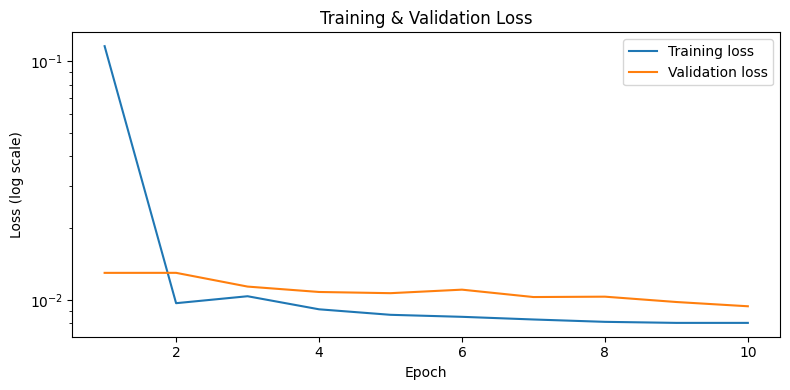

In [7]:
# ── 7. Train ──────────────────────────────────────────────────────────────
from train import train_model
model, history = train_model()

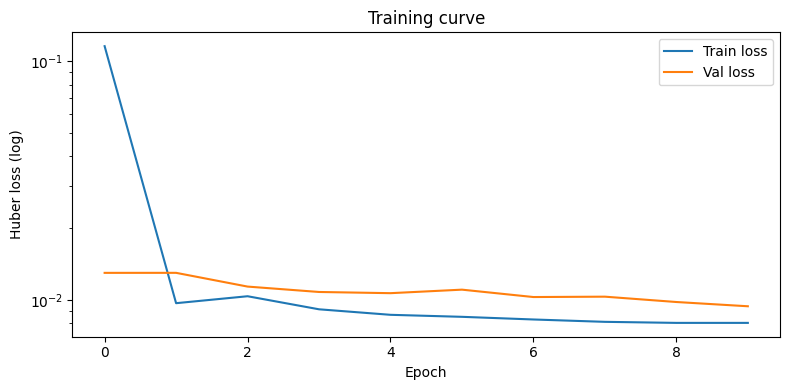

Best weights saved to: /content/drive/MyDrive/speech_enhancement/weights/model_best.h5


In [8]:
# ── 8. Plot loss curve ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

loss     = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(loss,     label='Train loss')
plt.plot(val_loss, label='Val loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Huber loss (log)')
plt.title('Training curve')
plt.legend()
plt.tight_layout()
plt.show()

import os
best_weights = os.path.join(C.WEIGHTS_DIR, 'model_best.h5')
if os.path.exists(best_weights):
    print(f'Best weights saved to: {best_weights}')
else:
    print('model_best.h5 not found (training may not have improved from epoch 1)')